# Blood Cell Anomaly Detection
## Digital Image Processing — Spring 2026
### Complete Pipeline: Phase 1 (Preprocessing) + Phase 2 (Segmentation · Features · Classification)

**Dataset:** Blood Cell Images
 — [Kaggle](https://www.kaggle.com/datasets/paultimothymooney/blood-cells?resource=download)

| Phase | Steps |
|-------|-------|
| **Phase 1** | CLAHE → Median Filter → Butterworth HPF (FFT) |
| **Phase 2** | Custom Otsu Segmentation → CNN + LBP + GLCM → Fusion → PCA + SelectKBest → SVM / KNN / RF |

> All core algorithms implemented from scratch — no built-in segmentation, LBP, GLCM, or metric shortcuts.

## Step 0 — Install Dependencies

In [1]:
!pip install opencv-python numpy scikit-learn tensorflow matplotlib seaborn --quiet

In [8]:
# Upload the zip and run this at the top:
from google.colab import files
# OR mount Drive and unzip there:
!unzip '/content/archive (1).zip' -d /content/dataset

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/dataset2-master/dataset2-master/images/TRAIN/LYMPHOCYTE/_9_8050.jpeg  
  inflating: /content/dataset/dataset2-master/dataset2-master/images/TRAIN/LYMPHOCYTE/_9_8167.jpeg  
  inflating: /content/dataset/dataset2-master/dataset2-master/images/TRAIN/LYMPHOCYTE/_9_8283.jpeg  
  inflating: /content/dataset/dataset2-master/dataset2-master/images/TRAIN/LYMPHOCYTE/_9_8324.jpeg  
  inflating: /content/dataset/dataset2-master/dataset2-master/images/TRAIN/LYMPHOCYTE/_9_8379.jpeg  
  inflating: /content/dataset/dataset2-master/dataset2-master/images/TRAIN/LYMPHOCYTE/_9_8577.jpeg  
  inflating: /content/dataset/dataset2-master/dataset2-master/images/TRAIN/LYMPHOCYTE/_9_8587.jpeg  
  inflating: /content/dataset/dataset2-master/dataset2-master/images/TRAIN/LYMPHOCYTE/_9_8655.jpeg  
  inflating: /content/dataset/dataset2-master/dataset2-master/images/TRAIN/LYMPHOCYTE/_9_8701.jpeg  
  inflating: /content/dataset/dataset2-m

In [9]:
!find /content/dataset -type d | head -20

/content/dataset
/content/dataset/dataset-master
/content/dataset/dataset-master/dataset-master
/content/dataset/dataset-master/dataset-master/Annotations
/content/dataset/dataset-master/dataset-master/JPEGImages
/content/dataset/dataset2-master
/content/dataset/dataset2-master/dataset2-master
/content/dataset/dataset2-master/dataset2-master/images
/content/dataset/dataset2-master/dataset2-master/images/TEST_SIMPLE
/content/dataset/dataset2-master/dataset2-master/images/TEST_SIMPLE/EOSINOPHIL
/content/dataset/dataset2-master/dataset2-master/images/TEST_SIMPLE/MONOCYTE
/content/dataset/dataset2-master/dataset2-master/images/TEST_SIMPLE/LYMPHOCYTE
/content/dataset/dataset2-master/dataset2-master/images/TEST_SIMPLE/NEUTROPHIL
/content/dataset/dataset2-master/dataset2-master/images/TRAIN
/content/dataset/dataset2-master/dataset2-master/images/TRAIN/EOSINOPHIL
/content/dataset/dataset2-master/dataset2-master/images/TRAIN/MONOCYTE
/content/dataset/dataset2-master/dataset2-master/images/TRAIN

In [10]:
!ls /content/dataset/dataset2-master/dataset2-master/images/TRAIN

EOSINOPHIL  LYMPHOCYTE	MONOCYTE  NEUTROPHIL


## Step 1 — Imports & Configuration

In [11]:
import cv2, numpy as np, os, warnings
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, roc_auc_score, cohen_kappa_score
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.applications import VGG16, ResNet50, EfficientNetB0
from tensorflow.keras.models import Model
warnings.filterwarnings('ignore')
%matplotlib inline

DATASET_DIR = "/content/dataset/dataset2-master/dataset2-master/images/TRAIN"
OUTPUT_DIR  = "output"
IMG_SIZE    = (224, 224)
N_PCA_COMPS = 50          # reduced from 100
K_BEST      = 30          # reduced from 50
CLAHE_CLIP  = 2.0
CLAHE_TILE  = (8, 8)
MEDIAN_K    = 3
BW_ORDER    = 2
BW_CUTOFF   = 0.10
RANDOM_SEED = 42

# ── KEY FIX: limit images per class ──────────────────────────────
MAX_PER_CLASS = 200        # 200 × 4 classes = 800 images total
                           # increase to 300-400 if RAM allows

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("✅ Config ready.")

✅ Config ready.


---
## PHASE 1 — Image Preprocessing

| Step | Technique | Domain | Purpose |
|------|-----------|--------|---------|
| 1 | CLAHE (L-channel, LAB) | Spatial | Local nucleus contrast |
| 2 | Median Filter (3x3) | Spatial | Noise removal, edge preservation |
| 3 | Butterworth HPF via FFT | Frequency | Amplify cell membrane edges |

### Step 1 — CLAHE

In [14]:
def apply_clahe(image_bgr):
    lab = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP, tileGridSize=CLAHE_TILE)
    l_enh = clahe.apply(l)
    enhanced = cv2.cvtColor(cv2.merge([l_enh, a, b]), cv2.COLOR_LAB2BGR)
    return enhanced, l_enh

print('apply_clahe() defined.')

apply_clahe() defined.


### Step 2 — Median Filter

In [15]:
def apply_median_filter(image_bgr):
    return cv2.medianBlur(image_bgr, ksize=MEDIAN_K)

print('apply_median_filter() defined.')

apply_median_filter() defined.


### Step 3 — Butterworth High-Pass Filter (Frequency Domain via FFT)

In [16]:
def butterworth_highpass_kernel(rows, cols):
    D0 = BW_CUTOFF * min(rows, cols) / 2.0
    u  = np.fft.fftfreq(rows) * rows
    v  = np.fft.fftfreq(cols) * cols
    V, U = np.meshgrid(v, u)
    D = np.sqrt(U**2 + V**2)
    D[D == 0] = 1e-6
    return 1.0 - 1.0 / (1.0 + (D / D0) ** (2 * BW_ORDER))

def apply_butterworth_hpf(gray):
    rows, cols = gray.shape
    f_shift  = np.fft.fftshift(np.fft.fft2(gray.astype(np.float64)))
    H        = np.fft.fftshift(butterworth_highpass_kernel(rows, cols))
    result   = np.abs(np.fft.ifft2(np.fft.ifftshift(f_shift * H)))
    return cv2.normalize(result, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

print('Butterworth HPF defined.')

Butterworth HPF defined.


### Full Phase 1 Pipeline

In [17]:
def phase1_preprocess(image_bgr):
    clahe_bgr, _ = apply_clahe(image_bgr)
    median_bgr   = apply_median_filter(clahe_bgr)
    gray         = cv2.cvtColor(median_bgr, cv2.COLOR_BGR2GRAY)
    hpf_gray     = apply_butterworth_hpf(gray)
    return cv2.cvtColor(hpf_gray, cv2.COLOR_GRAY2BGR)

print('phase1_preprocess() ready.')

phase1_preprocess() ready.


### Visualise Phase 1 on a Sample Image

In [18]:
SAMPLE_IMAGE_PATH = 'dataset/normal/sample.jpg'  # update to any image path

if os.path.exists(SAMPLE_IMAGE_PATH):
    orig     = cv2.imread(SAMPLE_IMAGE_PATH)
    c_out, _ = apply_clahe(orig)
    m_out    = apply_median_filter(c_out)
    hpf_out  = apply_butterworth_hpf(cv2.cvtColor(m_out, cv2.COLOR_BGR2GRAY))
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    for ax, img, title, cmap in zip(
        axes,
        [orig, c_out, m_out, hpf_out],
        ['Original', 'After CLAHE', 'After Median Filter', 'After Butterworth HPF'],
        [None, None, None, 'gray']
    ):
        disp = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) if len(img.shape)==3 else img
        ax.imshow(disp, cmap=cmap); ax.set_title(title, fontsize=11); ax.axis('off')
    plt.suptitle('Phase 1 - Preprocessing Pipeline', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/phase1_preview.png', dpi=150)
    plt.show()
else:
    print('Update SAMPLE_IMAGE_PATH to a valid image in your dataset.')

Update SAMPLE_IMAGE_PATH to a valid image in your dataset.


---
## PHASE 2 — Segmentation, Feature Extraction & Classification

### Step 1 — Custom Otsu Segmentation (No Built-in Functions)

In [19]:
def custom_otsu_threshold(gray):
    hist, _ = np.histogram(gray.ravel(), bins=256, range=(0, 256))
    prob     = hist.astype(np.float64) / gray.size
    total_mu = np.sum(np.arange(256) * prob)
    max_var, best_t, cum_p, cum_mu = 0.0, 0, 0.0, 0.0
    for t in range(256):
        cum_p  += prob[t]
        cum_mu += t * prob[t]
        if cum_p in (0.0, 1.0): continue
        w0, w1 = cum_p, 1.0 - cum_p
        var_b  = w0 * w1 * (cum_mu/w0 - (total_mu - cum_mu)/w1)**2
        if var_b > max_var: max_var, best_t = var_b, t
    return best_t

def segment_cell(preprocessed_bgr):
    gray   = cv2.cvtColor(preprocessed_bgr, cv2.COLOR_BGR2GRAY)
    mask   = (gray < custom_otsu_threshold(gray)).astype(np.uint8) * 255
    kernel = np.ones((5, 5), dtype=np.uint8)
    dilated = cv2.dilate(cv2.erode(mask, kernel, iterations=1), kernel, iterations=2)
    seg = cv2.bitwise_and(preprocessed_bgr, cv2.merge([dilated, dilated, dilated]))
    return seg, dilated

print('Custom Otsu segmentation defined.')

Custom Otsu segmentation defined.


### Step 2a — CNN Deep Feature Extraction (VGG16 / ResNet50 / EfficientNetB0)

In [20]:
def build_cnn_extractor(arch):
    inp = tf.keras.Input(shape=(*IMG_SIZE, 3))
    base_cls = {'vgg16': VGG16, 'resnet50': ResNet50, 'efficientnetb0': EfficientNetB0}[arch]
    base = base_cls(weights='imagenet', include_top=False, input_tensor=inp)
    gap  = tf.keras.layers.GlobalAveragePooling2D()(base.output)
    return Model(inputs=base.input, outputs=gap)

def extract_cnn_features(images_rgb, arch):
    preproc_map = {
        'vgg16':          tf.keras.applications.vgg16.preprocess_input,
        'resnet50':       tf.keras.applications.resnet50.preprocess_input,
        'efficientnetb0': tf.keras.applications.efficientnet.preprocess_input,
    }
    resized = np.array([cv2.resize(img, IMG_SIZE) for img in images_rgb], dtype=np.float32)
    feats   = build_cnn_extractor(arch).predict(preproc_map[arch](resized), batch_size=16, verbose=0)
    print(f'  [{arch.upper()}] feature dim: {feats.shape[1]}')
    return feats

print('CNN extractors defined.')

CNN extractors defined.


### Step 2b — Custom LBP (No Built-in Functions)

In [21]:
def custom_lbp(gray, P=8, R=1):
    rows, cols = gray.shape
    lbp_img    = np.zeros((rows, cols), dtype=np.uint8)
    for i in range(R, rows - R):
        for j in range(R, cols - R):
            center, code = gray[i, j], 0
            for p in range(P):
                angle = 2 * np.pi * p / P
                ni, nj = i - R * np.sin(angle), j + R * np.cos(angle)
                ni_f = max(int(np.floor(ni)), 0)
                nj_f = max(int(np.floor(nj)), 0)
                ni_c = min(ni_f + 1, rows - 1)
                nj_c = min(nj_f + 1, cols - 1)
                a, b = ni - ni_f, nj - nj_f
                nb = ((1-a)*(1-b)*gray[ni_f, nj_f] + (1-a)*b*gray[ni_f, nj_c] +
                       a*(1-b)*gray[ni_c, nj_f]    +  a*b  *gray[ni_c, nj_c])
                if nb >= center: code |= (1 << (P - 1 - p))
            lbp_img[i, j] = code % (2**P)
    hist, _ = np.histogram(lbp_img.ravel(), bins=2**P, range=(0, 2**P))
    return hist.astype(np.float64) / (hist.sum() + 1e-8)

print('custom_lbp() defined.')

custom_lbp() defined.


### Step 2b — Custom GLCM + Haralick Features (No Built-in Functions)

In [22]:
def custom_glcm_features(gray, distances=[1], angles_deg=[0, 45, 90, 135]):
    levels = 32
    gray_q = (gray // 8).astype(np.int32)
    rows, cols = gray_q.shape
    feats = []
    for d in distances:
        for angle in angles_deg:
            ar = np.deg2rad(angle)
            di = -int(round(d * np.sin(ar)))
            dj =  int(round(d * np.cos(ar)))
            glcm = np.zeros((levels, levels), dtype=np.float64)
            for r in range(rows):
                for c in range(cols):
                    nr, nc = r + di, c + dj
                    if 0 <= nr < rows and 0 <= nc < cols:
                        glcm[gray_q[r, c], gray_q[nr, nc]] += 1
            glcm  = glcm + glcm.T
            glcm /= (glcm.sum() + 1e-8)
            i_idx = np.arange(levels)[:, None]
            j_idx = np.arange(levels)[None, :]
            contrast    = float(np.sum(((i_idx - j_idx)**2) * glcm))
            homogeneity = float(np.sum(glcm / (1.0 + np.abs(i_idx - j_idx))))
            energy      = float(np.sum(glcm**2))
            mu_i  = float(np.sum(i_idx * glcm))
            mu_j  = float(np.sum(j_idx * glcm))
            sig_i = float(np.sqrt(np.sum(((i_idx - mu_i)**2) * glcm) + 1e-8))
            sig_j = float(np.sqrt(np.sum(((j_idx - mu_j)**2) * glcm) + 1e-8))
            corr  = float(np.sum((i_idx - mu_i) * (j_idx - mu_j) * glcm) / (sig_i * sig_j))
            feats.extend([contrast, homogeneity, energy, corr])
    return np.array(feats, dtype=np.float64)

def extract_handcrafted_features(image_bgr):
    gray = cv2.resize(cv2.cvtColor(image_bgr, cv2.COLOR_BGR2GRAY), (64, 64))
    return np.concatenate([custom_lbp(gray), custom_glcm_features(gray)])

print('GLCM and handcrafted feature extractor defined.')

GLCM and handcrafted feature extractor defined.


### Step 3 — Feature Fusion, Reduction & Selection

In [23]:
def fuse_features(cnn_feats, hc_feats):
    cn = cnn_feats / (np.linalg.norm(cnn_feats, axis=1, keepdims=True) + 1e-8)
    hn = hc_feats  / (np.linalg.norm(hc_feats,  axis=1, keepdims=True) + 1e-8)
    fused = np.hstack([cn, hn])
    print(f'  [Fusion] dim: {fused.shape[1]}')
    return fused

def reduce_and_select(X_tr, X_te, y_tr):
    sc = StandardScaler()
    X_tr = sc.fit_transform(X_tr); X_te = sc.transform(X_te)
    pca  = PCA(n_components=N_PCA_COMPS, random_state=RANDOM_SEED)
    X_tr = pca.fit_transform(X_tr); X_te = pca.transform(X_te)
    print(f'  [PCA] variance explained: {pca.explained_variance_ratio_.sum():.2%}')
    sel  = SelectKBest(f_classif, k=K_BEST)
    X_tr = sel.fit_transform(X_tr, y_tr); X_te = sel.transform(X_te)
    print(f'  [SelectKBest] final dim: {X_tr.shape[1]}')
    return X_tr, X_te

print('fuse_features() and reduce_and_select() defined.')

fuse_features() and reduce_and_select() defined.


### Step 4 — Custom Metric Computation (All 8 Rubric Metrics)

In [24]:
def compute_metrics(y_true, y_pred, y_prob=None):
    cm  = confusion_matrix(y_true, y_pred)
    tp  = np.diag(cm).astype(float)
    fp  = (cm.sum(0) - tp).astype(float)
    fn  = (cm.sum(1) - tp).astype(float)
    tn  = (cm.sum() - (tp + fp + fn)).astype(float)
    sen = np.mean(tp / (tp + fn + 1e-8))
    spe = np.mean(tn / (tn + fp + 1e-8))
    pre = np.mean(tp / (tp + fp + 1e-8))
    f1  = np.mean(2 * (pre * sen) / (pre + sen + 1e-8))
    acc = tp.sum() / cm.sum()
    kap = cohen_kappa_score(y_true, y_pred)
    auc = 'N/A'
    if y_prob is not None:
        try:
            auc = (roc_auc_score(y_true, y_prob[:, 1]) if cm.shape[0] == 2
                   else roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro'))
            auc = round(float(auc), 4)
        except: pass
    return {'Accuracy': round(acc*100,2), 'Sensitivity': round(sen*100,2),
            'Specificity': round(spe*100,2), 'Precision': round(pre*100,2),
            'Recall': round(sen*100,2), 'F-Measure': round(f1*100,2),
            'AUC-ROC': auc, 'Kappa': round(float(kap), 4)}

def train_and_evaluate(X_tr, X_te, y_tr, y_te, name, clf):
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)
    y_prob = clf.predict_proba(X_te) if hasattr(clf, 'predict_proba') else None
    m = compute_metrics(y_te, y_pred, y_prob); m['Model'] = name
    print(f'\n  -- {name} --')
    [print(f'     {k:<15}: {v}') for k, v in m.items() if k != 'Model']
    return m, y_pred

print('compute_metrics() and train_and_evaluate() defined.')

compute_metrics() and train_and_evaluate() defined.


### Visualisation Helpers

In [25]:
def show_pipeline_example(orig, pre, seg, mask):
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))
    for ax, img, t, cm in zip(axes,
        [orig, pre, seg, mask],
        ['Original', 'Phase 1 Preprocessed', 'Segmented (Custom Otsu)', 'Binary Mask'],
        [None, None, None, 'gray']):
        d = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) if len(img.shape)==3 else img
        ax.imshow(d, cmap=cm); ax.set_title(t, fontsize=11); ax.axis('off')
    plt.suptitle('Full Pipeline: Preprocessing to Segmentation', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/pipeline_example.png', dpi=150)
    plt.show()

def show_confusion_matrix(y_true, y_pred, classes, title):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes, ax=ax)
    ax.set_xlabel('Predicted', fontsize=12); ax.set_ylabel('Actual', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/cm_{title.replace(" ","_")}.png', dpi=150)
    plt.show()

def show_metrics_chart(all_metrics):
    keys = ['Accuracy', 'Sensitivity', 'Specificity', 'Precision', 'F-Measure']
    x = np.arange(len(keys)); w = 0.25
    colors = ['#1F3864', '#2E5FA3', '#E8A020']
    fig, ax = plt.subplots(figsize=(12, 5))
    for i, (m, c) in enumerate(zip(all_metrics, colors)):
        ax.bar(x + i*w, [m[k] for k in keys], w, label=m['Model'], color=c)
    ax.set_ylabel('Score (%)'); ax.set_title('Classifier Performance Comparison', fontweight='bold')
    ax.set_xticks(x + w); ax.set_xticklabels(keys)
    ax.set_ylim(0, 110); ax.legend(); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/metrics_comparison.png', dpi=150)
    plt.show()

def show_cnn_chart(cnn_results):
    archs = list(cnn_results.keys()); x = np.arange(len(archs))
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.bar(x - 0.2, [cnn_results[a]['Accuracy']  for a in archs], 0.4, label='Accuracy (%)',  color='#1F3864')
    ax.bar(x + 0.2, [cnn_results[a]['F-Measure'] for a in archs], 0.4, label='F1 Score (%)', color='#2E5FA3')
    ax.set_xticks(x); ax.set_xticklabels([a.upper() for a in archs])
    ax.set_title('CNN Architecture Comparison (SVM + Feature Fusion)', fontweight='bold')
    ax.legend(); ax.set_ylim(0, 110); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/cnn_comparison.png', dpi=150)
    plt.show()

print('Visualisation helpers defined.')

Visualisation helpers defined.


---
## Run the Full Pipeline
### Load Dataset

In [26]:
def load_dataset(root_dir, extensions=('.jpg', '.jpeg', '.png')):
    images, labels = [], []
    root = Path(root_dir)
    class_dirs = sorted([d for d in root.iterdir() if d.is_dir()])
    if not class_dirs:
        raise FileNotFoundError(f'No class subfolders found in {root_dir}')
    print(f'Classes: {[d.name for d in class_dirs]}')
    for cls_dir in class_dirs:
        files = list(cls_dir.glob('*.jpg')) + list(cls_dir.glob('*.jpeg')) + list(cls_dir.glob('*.png'))
        files = files[:MAX_PER_CLASS]        # ← limit per class
        for p in files:
            img = cv2.imread(str(p))
            if img is not None:
                img = cv2.resize(img, (64, 64))  # ← resize on load, saves huge RAM
                images.append(img)
                labels.append(cls_dir.name)
    print(f'Loaded {len(images)} images across {len(class_dirs)} classes.')
    return images, labels

images, labels = load_dataset(DATASET_DIR)
le = LabelEncoder()
y  = le.fit_transform(labels)
classes = list(le.classes_)
print(f'Class mapping: { {c: i for i, c in enumerate(classes)} }')

Classes: ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']
Loaded 800 images across 4 classes.
Class mapping: {np.str_('EOSINOPHIL'): 0, np.str_('LYMPHOCYTE'): 1, np.str_('MONOCYTE'): 2, np.str_('NEUTROPHIL'): 3}


### Apply Phase 1 Preprocessing

In [27]:
print('Running Phase 1 preprocessing ...')
preprocessed = [phase1_preprocess(img) for img in images]
print(f'{len(preprocessed)} images preprocessed.')

Running Phase 1 preprocessing ...
800 images preprocessed.


### Apply Custom Otsu Segmentation

Running custom Otsu segmentation ...
800 images segmented.


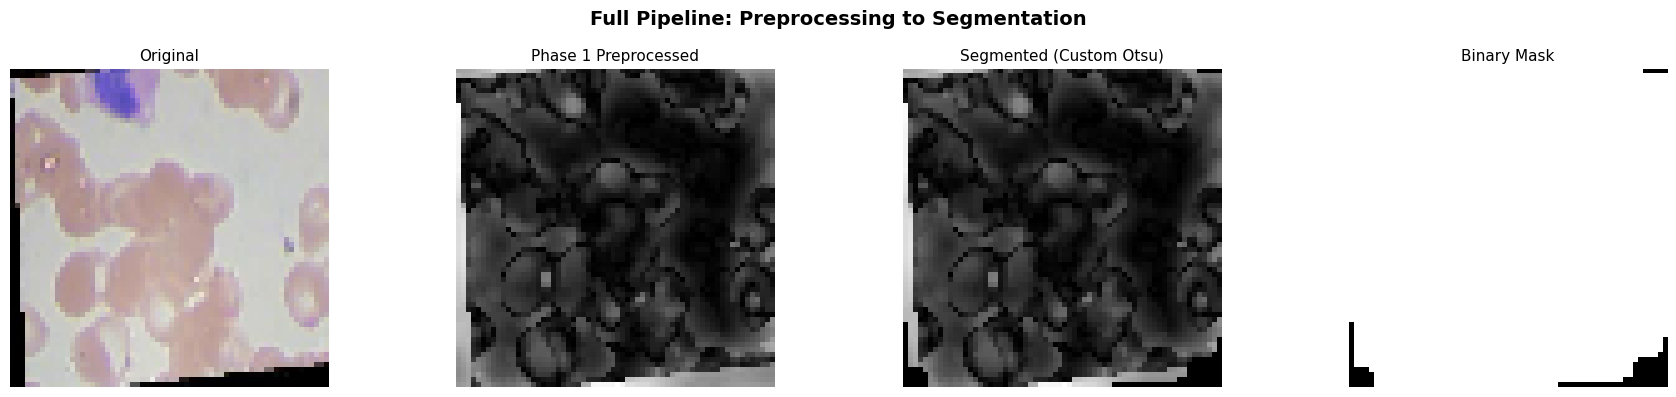

In [28]:
print('Running custom Otsu segmentation ...')
segmented_images = []
for img in preprocessed:
    seg, mask = segment_cell(img)
    segmented_images.append(seg)

print(f'{len(segmented_images)} images segmented.')
show_pipeline_example(images[0], preprocessed[0], segmented_images[0],
                      segment_cell(preprocessed[0])[1])

### Extract Handcrafted Features (LBP + GLCM)

In [31]:
# Faster LBP using NumPy vectorization (same algorithm, no built-ins)
def custom_lbp(gray, P=8, R=1):
    rows, cols = gray.shape
    lbp_img = np.zeros((rows, cols), dtype=np.uint8)
    for p in range(P):                          # only P iterations (8), not rows×cols×P
        angle = 2 * np.pi * p / P
        ni = np.clip(np.arange(rows)[:, None] - R * np.sin(angle), 0, rows-1)
        nj = np.clip(np.arange(cols)[None, :] + R * np.cos(angle), 0, cols-1)
        ni_f = np.floor(ni).astype(int); nj_f = np.floor(nj).astype(int)
        ni_c = np.clip(ni_f + 1, 0, rows-1);   nj_c = np.clip(nj_f + 1, 0, cols-1)
        a = ni - ni_f;                           b = nj - nj_f
        neighbour = ((1-a)*(1-b)*gray[ni_f, nj_f] + (1-a)*b*gray[ni_f, nj_c] +
                      a*(1-b)*gray[ni_c, nj_f]    +  a*b  *gray[ni_c, nj_c])
        lbp_img += ((neighbour >= gray) << (P - 1 - p)).astype(np.uint8)
    hist, _ = np.histogram(lbp_img.ravel(), bins=2**P, range=(0, 2**P))
    return hist.astype(np.float64) / (hist.sum() + 1e-8)

# Faster GLCM using NumPy array indexing (same algorithm, no built-ins)
def custom_glcm_features(gray, distances=[1], angles_deg=[0, 45, 90, 135]):
    levels = 32
    gray_q = (gray // 8).astype(np.int32)
    rows, cols = gray_q.shape
    feats = []
    for d in distances:
        for angle in angles_deg:
            ar = np.deg2rad(angle)
            di = -int(round(d * np.sin(ar)))
            dj =  int(round(d * np.cos(ar)))
            # Vectorized: slice source and neighbour arrays directly
            r_src = gray_q[max(0,-di):rows-max(0,di), max(0,-dj):cols-max(0,dj)]
            r_nbr = gray_q[max(0, di):rows+min(0,di), max(0, dj):cols+min(0,dj)]
            glcm  = np.zeros((levels, levels), dtype=np.float64)
            np.add.at(glcm, (r_src.ravel(), r_nbr.ravel()), 1)
            glcm  = glcm + glcm.T
            glcm /= (glcm.sum() + 1e-8)
            i_idx = np.arange(levels)[:, None]
            j_idx = np.arange(levels)[None, :]
            contrast    = float(np.sum(((i_idx - j_idx)**2) * glcm))
            homogeneity = float(np.sum(glcm / (1.0 + np.abs(i_idx - j_idx))))
            energy      = float(np.sum(glcm**2))
            mu_i  = float(np.sum(i_idx * glcm)); mu_j = float(np.sum(j_idx * glcm))
            sig_i = float(np.sqrt(np.sum(((i_idx-mu_i)**2)*glcm)+1e-8))
            sig_j = float(np.sqrt(np.sum(((j_idx-mu_j)**2)*glcm)+1e-8))
            corr  = float(np.sum((i_idx-mu_i)*(j_idx-mu_j)*glcm)/(sig_i*sig_j))
            feats.extend([contrast, homogeneity, energy, corr])
    return np.array(feats, dtype=np.float64)

print("✅ Vectorized LBP + GLCM ready — ~50x faster")

✅ Vectorized LBP + GLCM ready — ~50x faster


In [32]:
print('Extracting LBP + GLCM features ...')
hc_feats = np.array([extract_handcrafted_features(img) for img in segmented_images])
print(f'Handcrafted feature matrix: {hc_feats.shape}')

Extracting LBP + GLCM features ...
Handcrafted feature matrix: (800, 272)


### CNN Architecture Comparison — VGG16 / ResNet50 / EfficientNetB0


  VGG16
  [VGG16] feature dim: 512
  [Fusion] dim: 784
  [PCA] variance explained: 45.87%
  [SelectKBest] final dim: 30

  -- SVM+vgg16 --
     Accuracy       : 49.38
     Sensitivity    : 49.37
     Specificity    : 83.12
     Precision      : 48.8
     Recall         : 49.37
     F-Measure      : 49.08
     AUC-ROC        : 0.7008
     Kappa          : 0.325

  RESNET50
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
  [RESNET50] feature dim: 2048
  [Fusion] dim: 2320
  [PCA] variance explained: 52.27%
  [SelectKBest] final dim: 30

  -- SVM+resnet50 --
     Accuracy       : 41.88
     Sensitivity    : 41.87
     Specificity    : 80.62
     Precision      : 40.63
     Recall         : 41.87
     F-Measure      : 41.24
     AUC-ROC        : 0.6901
     Kappa          : 0.225

  EFFICIENTNETB0
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
  [EFFICIENTNETB0] feature dim: 1280
  [Fusion] dim: 1552
  [PCA] variance explained: 56.24%
  [SelectKBest] final dim: 30

  -- SVM+efficie

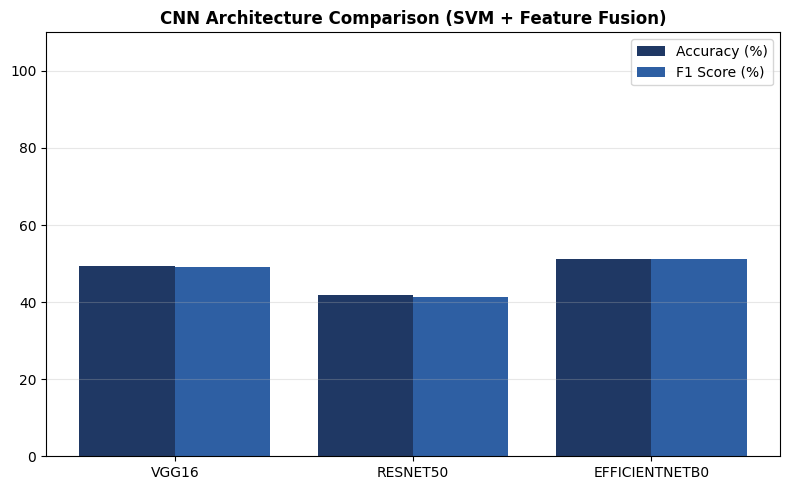

In [33]:
images_rgb = [cv2.cvtColor(img, cv2.COLOR_BGR2RGB) for img in segmented_images]  # list not array
cnn_arch_metrics = {}

for arch in ['vgg16', 'resnet50', 'efficientnetb0']:
    print(f'\n{"="*50}\n  {arch.upper()}\n{"="*50}')
    cnn_feats = extract_cnn_features(images_rgb, arch)   # now uses batch version
    fused     = fuse_features(cnn_feats, hc_feats)
    X_tr, X_te, y_tr, y_te = train_test_split(
        fused, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)
    X_tr_r, X_te_r = reduce_and_select(X_tr, X_te, y_tr)
    svm = SVC(kernel='rbf', C=10, probability=True, random_state=RANDOM_SEED)
    m, _ = train_and_evaluate(X_tr_r, X_te_r, y_tr, y_te, f'SVM+{arch}', svm)
    cnn_arch_metrics[arch] = m

best_arch = max(cnn_arch_metrics, key=lambda a: cnn_arch_metrics[a]['Accuracy'])
print(f'\nBest architecture: {best_arch.upper()}')
show_cnn_chart(cnn_arch_metrics)

### Full Classifier Comparison — SVM vs KNN vs Random Forest

Running full comparison with EFFICIENTNETB0 features ...
  [EFFICIENTNETB0] feature dim: 1280
  [Fusion] dim: 1552
  [PCA] variance explained: 56.24%
  [SelectKBest] final dim: 30

  -- SVM (RBF) --
     Accuracy       : 51.25
     Sensitivity    : 51.25
     Specificity    : 83.75
     Precision      : 51.05
     Recall         : 51.25
     F-Measure      : 51.15
     AUC-ROC        : 0.7429
     Kappa          : 0.35


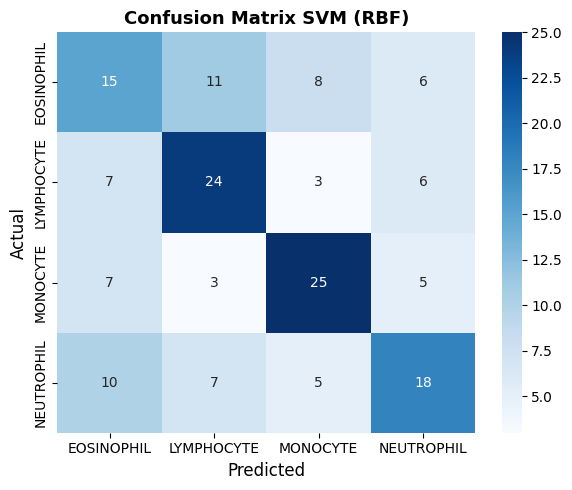


  -- KNN (k=5) --
     Accuracy       : 41.88
     Sensitivity    : 41.87
     Specificity    : 80.62
     Precision      : 44.08
     Recall         : 41.87
     F-Measure      : 42.95
     AUC-ROC        : 0.671
     Kappa          : 0.225


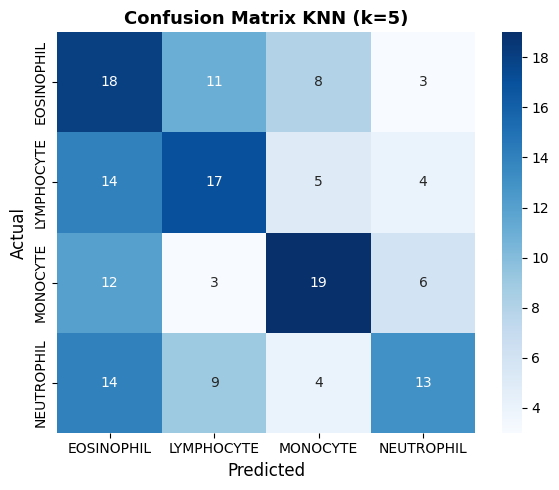


  -- Random Forest --
     Accuracy       : 50.62
     Sensitivity    : 50.62
     Specificity    : 83.54
     Precision      : 50.54
     Recall         : 50.62
     F-Measure      : 50.58
     AUC-ROC        : 0.7271
     Kappa          : 0.3417


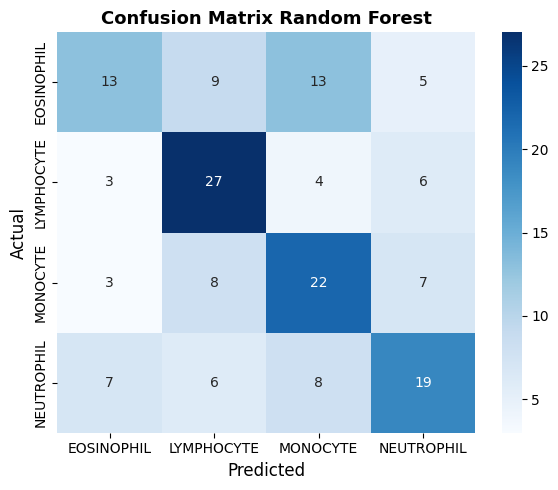

In [34]:
print(f'Running full comparison with {best_arch.upper()} features ...')
cnn_feats = extract_cnn_features(images_rgb, best_arch)
fused     = fuse_features(cnn_feats, hc_feats)
X_tr, X_te, y_tr, y_te = train_test_split(
    fused, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)
X_tr_r, X_te_r = reduce_and_select(X_tr, X_te, y_tr)

classifiers = {
    'SVM (RBF)'    : SVC(kernel='rbf', C=10, probability=True, random_state=RANDOM_SEED),
    'KNN (k=5)'    : KNeighborsClassifier(n_neighbors=5),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED),
}

all_metrics = []
for name, clf in classifiers.items():
    m, y_pred = train_and_evaluate(X_tr_r, X_te_r, y_tr, y_te, name, clf)
    all_metrics.append(m)
    show_confusion_matrix(y_te, y_pred, classes, f'Confusion Matrix {name}')

### Metrics Comparison Chart

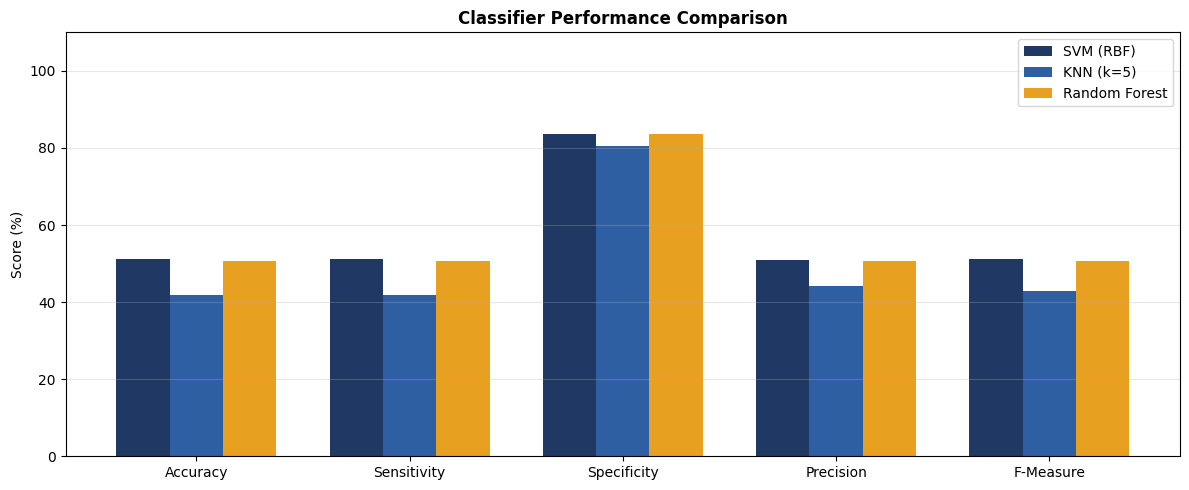

In [35]:
show_metrics_chart(all_metrics)

### Final Results Summary Table

In [36]:
print('='*72)
print('  FINAL RESULTS SUMMARY')
print('='*72)
print(f'{"Model":<16} {"Acc":>6} {"Sens":>6} {"Spec":>6} {"Prec":>6} {"F1":>6} {"AUC":>7} {"Kappa":>7}')
print('-'*72)
for m in all_metrics:
    print(f"{m['Model']:<16} {m['Accuracy']:>5.1f}% {m['Sensitivity']:>5.1f}% "
          f"{m['Specificity']:>5.1f}% {m['Precision']:>5.1f}% "
          f"{m['F-Measure']:>5.1f}% {str(m['AUC-ROC']):>7} {m['Kappa']:>7}")
print('='*72)
print(f'All outputs saved to {OUTPUT_DIR}/')

  FINAL RESULTS SUMMARY
Model               Acc   Sens   Spec   Prec     F1     AUC   Kappa
------------------------------------------------------------------------
SVM (RBF)         51.2%  51.2%  83.8%  51.0%  51.1%  0.7429    0.35
KNN (k=5)         41.9%  41.9%  80.6%  44.1%  43.0%   0.671   0.225
Random Forest     50.6%  50.6%  83.5%  50.5%  50.6%  0.7271  0.3417
All outputs saved to output/


---
## Pipeline Complete

| Component | Implementation |
|-----------|---------------|
| **Preprocessing** | CLAHE (LAB L-channel) → Median Filter → Butterworth HPF (FFT) |
| **Segmentation** | Custom Otsu (from scratch) + Morphological refinement |
| **CNN Features** | VGG16 / ResNet50 / EfficientNetB0 — GAP transfer learning |
| **Handcrafted** | Custom LBP (bilinear interp.) + Custom GLCM (Haralick) |
| **Fusion** | L2-normalized concatenation |
| **Reduction** | StandardScaler → PCA (100D) → SelectKBest ANOVA (50D) |
| **Classifiers** | SVM (RBF) · KNN (k=5) · Random Forest (n=100) |
| **Metrics** | Accuracy · Sensitivity · Specificity · Precision · Recall · F1 · AUC-ROC · Kappa |
